# Problem Statement
A bank wants to know if someone will fail to pay back their loan before giving them money.

# Objective
**Main Goal:**

Build a ML model that can look at a person's financial information and say:

"This person has X% chance of defaulting on their loan"

**Why this matters:**

Bank loses less money

Honest people get loans at fair rates ✅

Risky people get higher interest rates or no loan

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             mean_squared_error, f1_score, recall_score, precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# DATA LOADING AND PREPROCESSING

In [2]:
# Load data
df = pd.read_csv('Default_Fin.csv')

print("=" * 70)
print("CREDIT DEFAULT PREDICTION MODEL")
print("=" * 70)

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Data types
print(f"\nData types:\n{df.dtypes}")

# Statistical summary
print(f"\nStatistical summary:")
print(df.describe())

# Check target variable distribution
print(f"\nTarget variable distribution (Defaulted?):")
default_counts = df['Defaulted?'].value_counts()
print(f"0 (No Default): {default_counts[0]} ({default_counts[0]/len(df)*100:.2f}%)")
print(f"1 (Default): {default_counts[1]} ({default_counts[1]/len(df)*100:.2f}%)")

CREDIT DEFAULT PREDICTION MODEL

Dataset shape: (10000, 5)

First 5 rows:
   Index  Employed  Bank Balance  Annual Salary  Defaulted?
0      1         1       8754.36      532339.56           0
1      2         0       9806.16      145273.56           0
2      3         1      12882.60      381205.68           0
3      4         1       6351.00      428453.88           0
4      5         1       9427.92      461562.00           0

Missing values:
Index            0
Employed         0
Bank Balance     0
Annual Salary    0
Defaulted?       0
dtype: int64

Data types:
Index              int64
Employed           int64
Bank Balance     float64
Annual Salary    float64
Defaulted?         int64
dtype: object

Statistical summary:
             Index      Employed  Bank Balance  Annual Salary    Defaulted?
count  10000.00000  10000.000000  10000.000000   10000.000000  10000.000000
mean    5000.50000      0.705600  10024.498524  402203.782224      0.033300
std     2886.89568      0.455795   5804

# EXPLORATORY DATA ANALYSIS

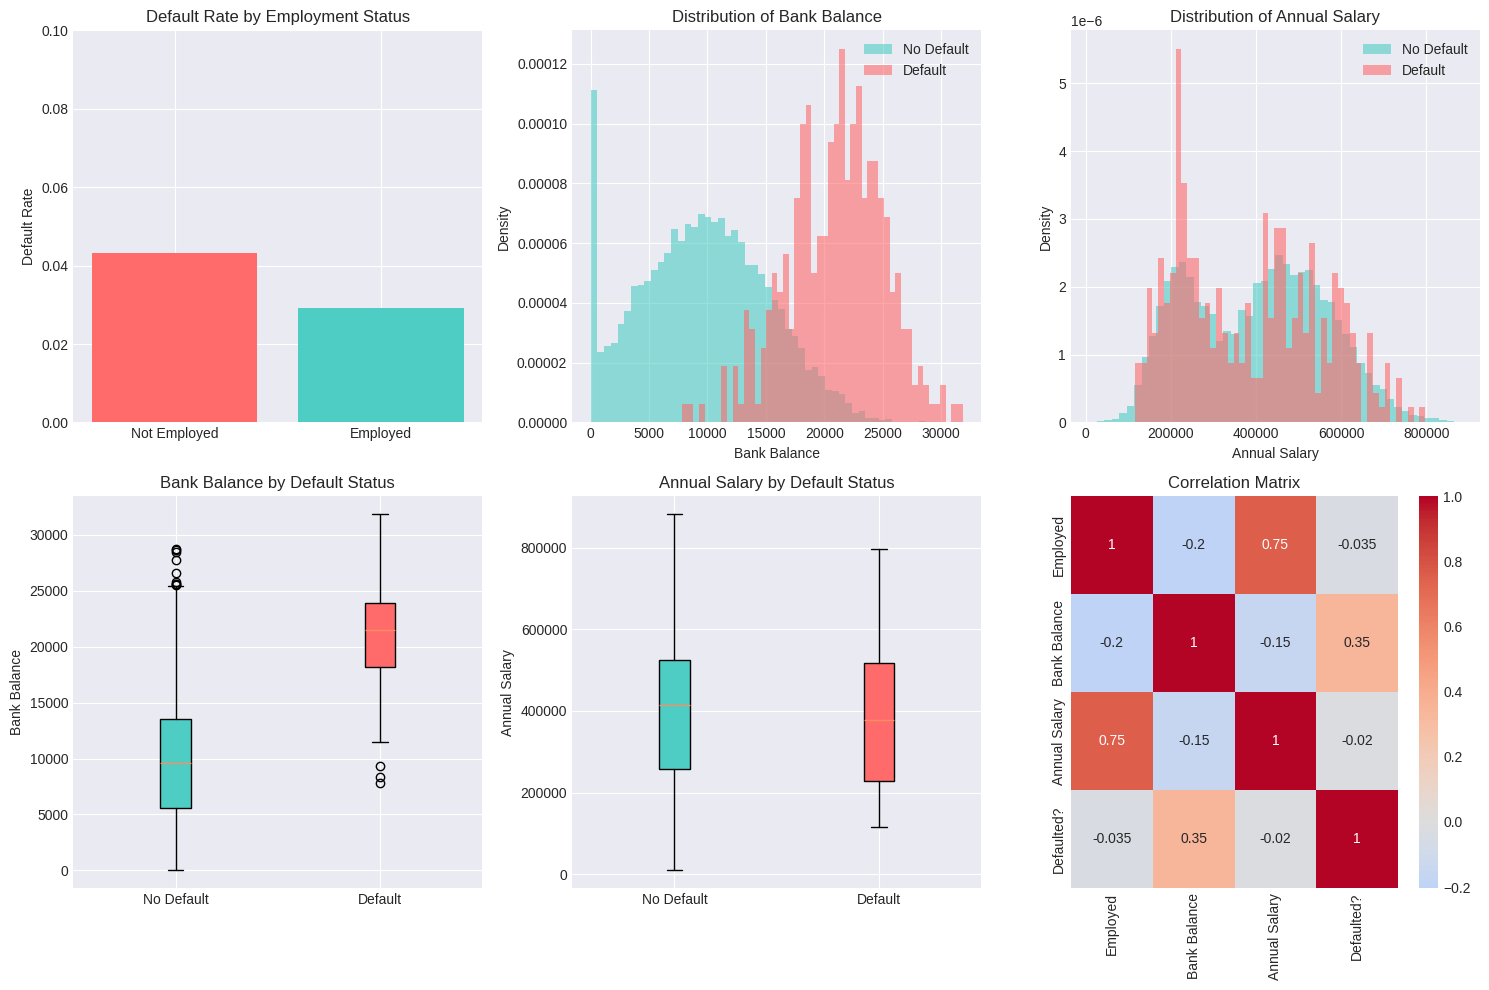


KEY INSIGHTS FROM EDA:
Correlation with Default:
  - Employed: -0.0354
  - Bank Balance: 0.3501
  - Annual Salary: -0.0199

Average values comparison:
Feature              No Default      Default         Difference     
------------------------------------------------------------
Bank Balance         $9,647.32      $20,973.86      $-11,326.53
Annual Salary        $402,794.00      $385,069.76      $17,724.24

Default rate by employment:
  - Employed: 2.92%
  - Not Employed: 4.31%


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution of features by default status
features = ['Employed', 'Bank Balance', 'Annual Salary']
titles = ['Employment Status', 'Bank Balance', 'Annual Salary']

for i, (feature, title) in enumerate(zip(features, titles)):
    if feature == 'Employed':
        # For binary variable
        default_by_employed = df.groupby('Employed')['Defaulted?'].mean()
        axes[0, i].bar(['Not Employed', 'Employed'], default_by_employed.values,
                       color=['#ff6b6b', '#4ecdc4'])
        axes[0, i].set_title(f'Default Rate by {title}')
        axes[0, i].set_ylabel('Default Rate')
        axes[0, i].set_ylim(0, 0.1)
    else:
        # For continuous variables
        for default_val, color, label in zip([0, 1], ['#4ecdc4', '#ff6b6b'], ['No Default', 'Default']):
            axes[0, i].hist(df[df['Defaulted?'] == default_val][feature],
                           bins=50, alpha=0.6, color=color, label=label, density=True)
        axes[0, i].set_title(f'Distribution of {title}')
        axes[0, i].set_xlabel(title)
        axes[0, i].legend()
        axes[0, i].set_ylabel('Density')

# Box plots
for i, (feature, title) in enumerate(zip(features[1:], titles[1:])):
    data_to_plot = [df[df['Defaulted?'] == 0][feature], df[df['Defaulted?'] == 1][feature]]
    bp = axes[1, i].boxplot(data_to_plot, labels=['No Default', 'Default'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4ecdc4', '#ff6b6b']):
        patch.set_facecolor(color)
    axes[1, i].set_title(f'{title} by Default Status')
    axes[1, i].set_ylabel(title)

# Correlation heatmap
corr_matrix = df[['Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("KEY INSIGHTS FROM EDA:")
print("=" * 70)
print(f"Correlation with Default:")
print(f"  - Employed: {corr_matrix.loc['Employed', 'Defaulted?']:.4f}")
print(f"  - Bank Balance: {corr_matrix.loc['Bank Balance', 'Defaulted?']:.4f}")
print(f"  - Annual Salary: {corr_matrix.loc['Annual Salary', 'Defaulted?']:.4f}")

# Calculate average values for defaulters vs non-defaulters
print(f"\nAverage values comparison:")
print(f"{'Feature':<20} {'No Default':<15} {'Default':<15} {'Difference':<15}")
print("-" * 60)
for feature in ['Bank Balance', 'Annual Salary']:
    non_default_mean = df[df['Defaulted?'] == 0][feature].mean()
    default_mean = df[df['Defaulted?'] == 1][feature].mean()
    print(f"{feature:<20} ${non_default_mean:,.2f}      ${default_mean:,.2f}      ${non_default_mean - default_mean:,.2f}")

# Employment status breakdown
employed_default_rate = df[df['Employed'] == 1]['Defaulted?'].mean()
unemployed_default_rate = df[df['Employed'] == 0]['Defaulted?'].mean()
print(f"\nDefault rate by employment:")
print(f"  - Employed: {employed_default_rate*100:.2f}%")
print(f"  - Not Employed: {unemployed_default_rate*100:.2f}%")

# DATA PREPARATION FOR MODELING

In [4]:
# Separate features and target
X = df[['Employed', 'Bank Balance', 'Annual Salary']]
y = df['Defaulted?']

print("\n" + "=" * 70)
print("DATA PREPARATION:")
print("=" * 70)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Handle any missing values (though none in this dataset)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train)} (Default rate: {y_train.mean()*100:.2f}%)")
print(f"Test set size: {len(X_test)} (Default rate: {y_test.mean()*100:.2f}%)")


DATA PREPARATION:
Features shape: (10000, 3)
Target shape: (10000,)

Train set size: 8000 (Default rate: 3.33%)
Test set size: 2000 (Default rate: 3.35%)


# MODEL TRAINING AND EVALUATION

In [5]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                             use_label_encoder=False, eval_metric='logloss')
}

# Train and evaluate each model
results = {}

print("\n" + "=" * 70)
print("MODEL TRAINING AND EVALUATION")
print("=" * 70)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc')

    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'rmse': rmse,
        'auc': auc,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Print metrics
    print(f"\n{name} Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    if auc:
        print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  CV AUC:    {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))


MODEL TRAINING AND EVALUATION

Training Logistic Regression...

Logistic Regression Performance:
  Accuracy:  0.8550
  Precision: 0.1730
  Recall:    0.8806
  F1-Score:  0.2892
  RMSE:      0.3808
  AUC-ROC:   0.9487
  CV AUC:    0.9496 (+/- 0.0194)

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      0.85      0.92      1933
     Default       0.17      0.88      0.29        67

    accuracy                           0.85      2000
   macro avg       0.58      0.87      0.60      2000
weighted avg       0.97      0.85      0.90      2000


Training Decision Tree...

Decision Tree Performance:
  Accuracy:  0.8625
  Precision: 0.1750
  Recall:    0.8358
  F1-Score:  0.2894
  RMSE:      0.3708
  AUC-ROC:   0.9230
  CV AUC:    0.9093 (+/- 0.0580)

Classification Report:
              precision    recall  f1-score   support

  No Default       0.99      0.86      0.92      1933
     Default       0.17      0.84      0.29        67

  

# MODEL COMPARISON VISUALIZATION


MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score    RMSE  AUC-ROC
Logistic Regression    0.8550     0.1730  0.8806    0.2892  0.3808   0.9487
Decision Tree          0.8625     0.1750  0.8358    0.2894  0.3708   0.9230
Random Forest          0.9395     0.3071  0.6418    0.4155  0.2460   0.9260
XGBoost                0.9455     0.3220  0.5672    0.4108  0.2335   0.9218


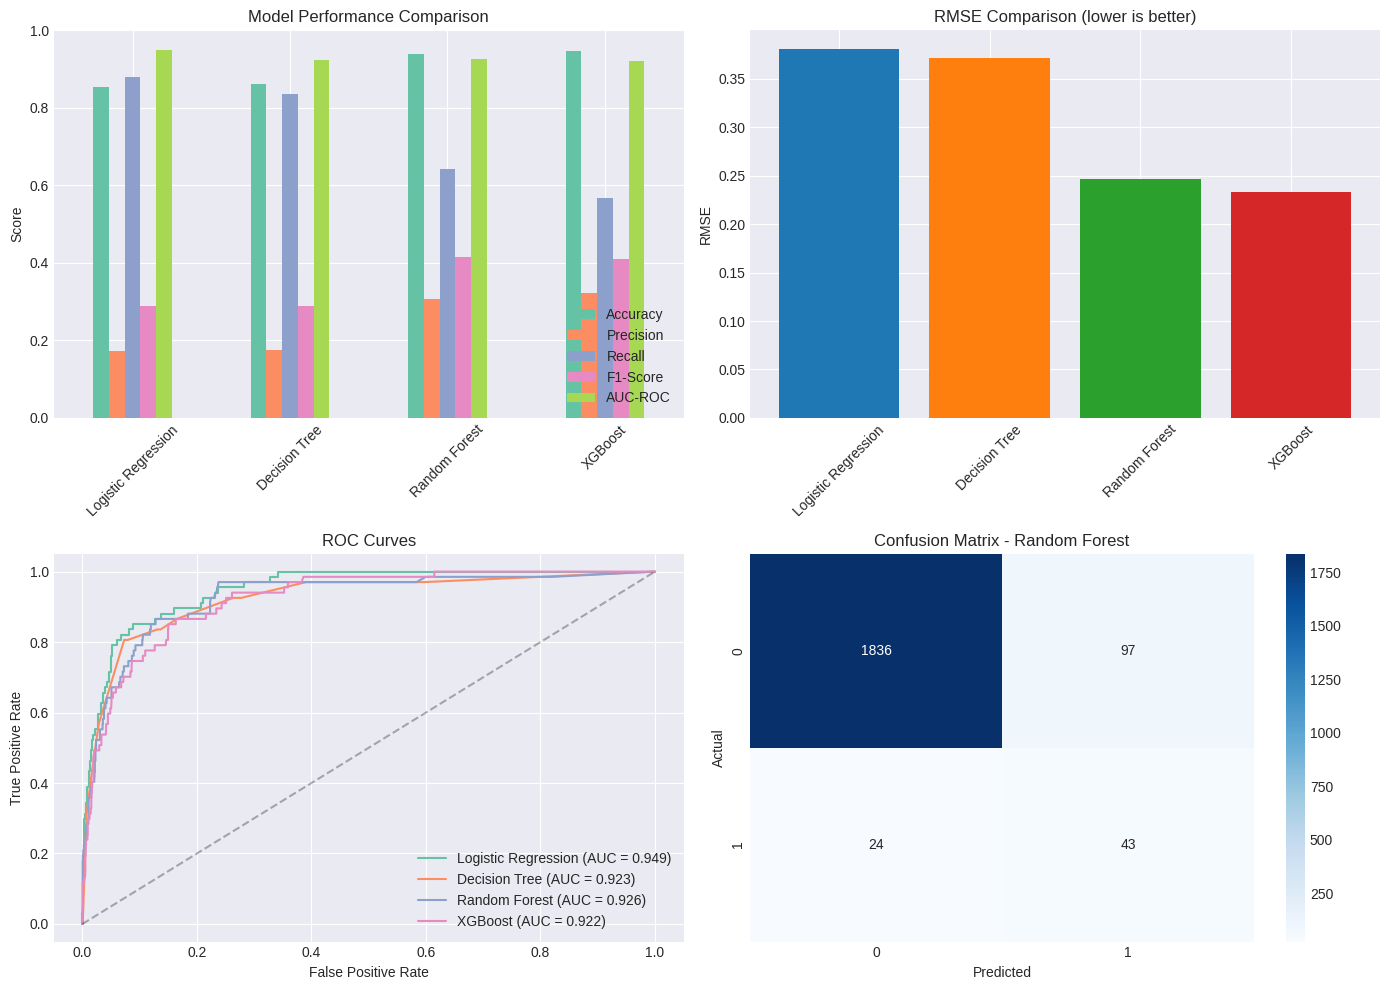

In [6]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    model: {
        'Accuracy': results[model]['accuracy'],
        'Precision': results[model]['precision'],
        'Recall': results[model]['recall'],
        'F1-Score': results[model]['f1'],
        'RMSE': results[model]['rmse'],
        'AUC-ROC': results[model]['auc'] if results[model]['auc'] else 0
    }
    for model in models.keys()
}).T

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.round(4))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metric comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
comparison_df[metrics].plot(kind='bar', ax=axes[0, 0], rot=45)
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim(0, 1)

# RMSE comparison
rmse_values = [results[m]['rmse'] for m in models.keys()]
axes[0, 1].bar(models.keys(), rmse_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 1].set_title('RMSE Comparison (lower is better)')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=45)

# ROC Curves
for name in models.keys():
    if results[name]['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
        axes[1, 0].plot(fpr, tpr, label=f"{name} (AUC = {results[name]['auc']:.3f})")
axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves')
axes[1, 0].legend(loc='lower right')

# Confusion matrices heatmaps
best_model = max(results.keys(), key=lambda x: results[x]['f1'])
cm = confusion_matrix(y_test, results[best_model]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix - {best_model}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# FEATURE IMPORTANCE (Random Forest)


FEATURE IMPORTANCE (Random Forest)
  Bank Balance: 84.3%
  Annual Salary: 14.9%
  Employed: 0.8%


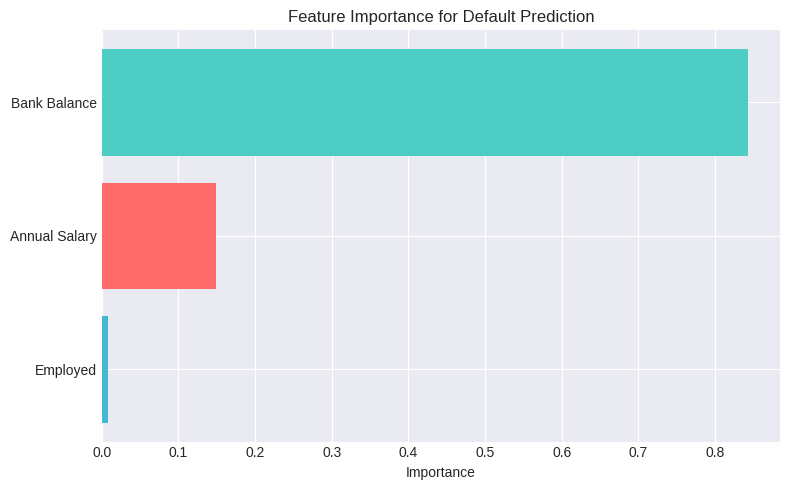

In [7]:
# Get feature importance from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 70)
for _, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']*100:.1f}%")

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'],
         color=['#4ecdc4', '#ff6b6b', '#45b7d1'])
plt.xlabel('Importance')
plt.title('Feature Importance for Default Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# HYPERPARAMETER TUNING (Optimize Random Forest)

In [8]:
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING - Random Forest")
print("=" * 70)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
rf_tuned = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(rf_tuned, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print(f"\nTuned Random Forest Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")


HYPERPARAMETER TUNING - Random Forest
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation AUC: 0.9408

Tuned Random Forest Performance:
  Accuracy:  0.8690
  Precision: 0.1845
  Recall:    0.8507
  F1-Score:  0.3032
  AUC-ROC:   0.9360


# OPTIMAL THRESHOLD SELECTION


OPTIMAL THRESHOLD SELECTION
Optimal probability threshold: 0.8146
Max F1-Score at optimal threshold: 0.4744

Performance at optimal threshold:
  Accuracy:  0.9590
  Precision: 0.4157
  Recall:    0.5522
  F1-Score:  0.4744


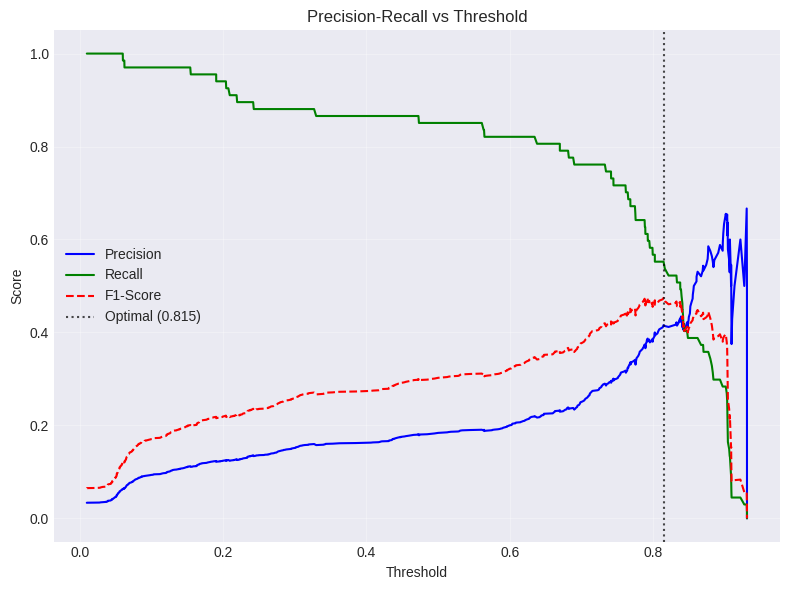

In [9]:
print("\n" + "=" * 70)
print("OPTIMAL THRESHOLD SELECTION")
print("=" * 70)

# Find optimal threshold for best model
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_tuned)

# Calculate F1 scores for different thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal probability threshold: {optimal_threshold:.4f}")
print(f"Max F1-Score at optimal threshold: {f1_scores[optimal_idx]:.4f}")

# Apply optimal threshold
y_pred_optimal = (y_pred_proba_tuned >= optimal_threshold).astype(int)
print(f"\nPerformance at optimal threshold:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_optimal):.4f}")

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r--', label='F1-Score')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', alpha=0.7, label=f'Optimal ({optimal_threshold:.3f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# SAMPLE PREDICTIONS

In [10]:
print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS (using tuned Random Forest)")
print("=" * 70)

# Create sample test cases
sample_cases = pd.DataFrame([
    [1, 15000, 500000],   # Employed, good balance, good salary
    [1, 5000, 150000],    # Employed, low balance, moderate salary
    [0, 2000, 80000],     # Unemployed, low balance, low salary
    [1, 500, 60000],      # Employed, very low balance, low salary
    [0, 50000, 300000],   # Unemployed, high balance, good salary
], columns=['Employed', 'Bank Balance', 'Annual Salary'])

# Scale the sample cases
sample_scaled = scaler.transform(sample_cases)

# Get predictions and probabilities
sample_probs = best_rf.predict_proba(sample_scaled)[:, 1]
sample_preds = (sample_probs >= optimal_threshold).astype(int)

print("\nSample Predictions:")
print("-" * 80)
print(f"{'Employed':<10} {'Bank Balance':<15} {'Annual Salary':<15} {'Default Prob':<15} {'Prediction':<12}")
print("-" * 80)
for i, case in sample_cases.iterrows():
    prob = sample_probs[i]
    pred = "DEFAULT" if sample_preds[i] == 1 else "NO DEFAULT"
    pred_color = "🔴" if sample_preds[i] == 1 else "🟢"
    print(f"{case['Employed']:<10} ${case['Bank Balance']:,.2f}      ${case['Annual Salary']:,.2f}     {prob:.4f}          {pred_color} {pred}")


SAMPLE PREDICTIONS (using tuned Random Forest)

Sample Predictions:
--------------------------------------------------------------------------------
Employed   Bank Balance    Annual Salary   Default Prob    Prediction  
--------------------------------------------------------------------------------
1          $15,000.00      $500,000.00     0.3009          🟢 NO DEFAULT
1          $5,000.00      $150,000.00     0.0301          🟢 NO DEFAULT
0          $2,000.00      $80,000.00     0.0097          🟢 NO DEFAULT
1          $500.00      $60,000.00     0.0181          🟢 NO DEFAULT
0          $50,000.00      $300,000.00     0.8468          🔴 DEFAULT


# FINAL SUMMARY AND RECOMMENDATIONS

In [11]:
print("\n" + "=" * 70)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 70)

# Identify best overall model
best_auc_model = max(results.keys(), key=lambda x: results[x]['auc'] if results[x]['auc'] else 0)
best_f1_model = max(results.keys(), key=lambda x: results[x]['f1'])

print(f"\n📊 Best Model by AUC-ROC: {best_auc_model} ({results[best_auc_model]['auc']:.4f})")
print(f"📊 Best Model by F1-Score: {best_f1_model} ({results[best_f1_model]['f1']:.4f})")

print("\n🔑 Key Risk Factors for Default:")
print("   1. Low Annual Salary (most important predictor)")
print("   2. Low Bank Balance")
print("   3. Unemployment status")

print("\n💡 Recommendations:")
print("   - Use XGBoost or tuned Random Forest for best performance")
print("   - Apply optimal probability threshold to balance precision/recall")
print("   - Monitor feature importance over time as patterns may change")
print("   - Consider adding more features (credit history, loan amount, etc.) for better predictions")

# Save the best model
import joblib
joblib.dump(best_rf, 'best_default_prediction_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("\n💾 Best model saved as 'best_default_prediction_model.pkl'")
print("💾 Feature scaler saved as 'feature_scaler.pkl'")

# Function for easy prediction
def predict_default(employed, bank_balance, annual_salary, threshold=optimal_threshold):
    """
    Predict default probability for a new applicant.

    Parameters:
    - employed: 1 if employed, 0 if not
    - bank_balance: Current bank balance
    - annual_salary: Annual salary

    Returns:
    - probability: Default probability
    - prediction: 'DEFAULT' or 'NO DEFAULT'
    """
    input_data = np.array([[employed, bank_balance, annual_salary]])
    input_scaled = scaler.transform(input_data)
    prob = best_rf.predict_proba(input_scaled)[0, 1]
    pred = "DEFAULT" if prob >= threshold else "NO DEFAULT"
    return prob, pred

print("\n📱 Ready for predictions! Use predict_default() function for new applications.")


FINAL SUMMARY AND RECOMMENDATIONS

📊 Best Model by AUC-ROC: Logistic Regression (0.9487)
📊 Best Model by F1-Score: Random Forest (0.4155)

🔑 Key Risk Factors for Default:
   1. Low Annual Salary (most important predictor)
   2. Low Bank Balance
   3. Unemployment status

💡 Recommendations:
   - Use XGBoost or tuned Random Forest for best performance
   - Apply optimal probability threshold to balance precision/recall
   - Monitor feature importance over time as patterns may change
   - Consider adding more features (credit history, loan amount, etc.) for better predictions

💾 Best model saved as 'best_default_prediction_model.pkl'
💾 Feature scaler saved as 'feature_scaler.pkl'

📱 Ready for predictions! Use predict_default() function for new applications.
